<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [68]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy


### 1. Definicion del Corpus
Usé el texto completo de Drácula de Bram Stoker en español, desde textos.info. Lo elegí porque es un texto largo con un vocabulario amplio y variado util para entrenar un modelo de lenguaje a nivel de caracteres.

In [69]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [70]:
raw_html = urllib.request.urlopen('https://www.textos.info/bram-stoker/dracula/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [71]:
print(f"Longitud del corpus: {len(article_text):,} caracteres")
print(f"\nPrimeros 500 caracteres:\n{article_text[:500]}")

Longitud del corpus: 943,242 caracteres

Primeros 500 caracteres:
 bistritz, 3 de mayo. salí de münich a las 8:35 de la noche del primero de mayo, llegué a viena a
la mañana siguiente, temprano; debí haber llegado a las seis cuarenta y seis; el tren llevaba una hora de
retraso. budapest parece un lugar maravilloso, a juzgar por lo poco que pude ver de ella desde el tren y
por la pequeña caminata que di por sus calles. temí alejarme mucho de la estación, ya que, como
habíamos llegado tarde, saldríamos lo más cerca posible de la hora fijada. la impresión que tuv


### 2. Definiendo tamaño del contexto
Como el modelo de lenguaje es por caracteres, todo el corpus puede ser  considerado un único documento y el tamaño de contexto puede elegirse
con mayor libertad en comparación a un modelo tokenizado por palabras.
Esto se debe a que los patrones importantes (sílabas, palabras, frases
cortas) aparecen en distancias cortas, por lo que una ventana de 100
caracteres es suficiente para capturar la estructura del texto.

In [72]:
# seleccionamos el tamaño de contexto
max_context_size = 100

###  3. Tokenizar

In [73]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [74]:
# creamos vocabulario de los caracteres unicos del libro
chars_vocab = set(article_text)
len(chars_vocab)

67

In [75]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

In [76]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [77]:
print(f"Primeros 100 tokens: {tokenized_text[:100]}")

Primeros 100 tokens: [45, 33, 16, 28, 42, 4, 16, 42, 39, 48, 45, 40, 45, 35, 46, 45, 25, 14, 53, 11, 41, 45, 28, 14, 58, 7, 45, 35, 46, 45, 25, 64, 65, 16, 49, 26, 45, 14, 45, 58, 14, 28, 45, 37, 5, 40, 56, 45, 35, 46, 45, 58, 14, 45, 65, 11, 49, 26, 46, 45, 35, 46, 58, 45, 31, 4, 16, 25, 46, 4, 11, 45, 35, 46, 45, 25, 14, 53, 11, 48, 45, 58, 58, 46, 19, 60, 15, 45, 14, 45, 36, 16, 46, 65, 14, 45, 14, 47, 58, 14]


### 4. Organizando y estructurando el dataset

In [78]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [79]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [80]:
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

In [81]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [82]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

Para estructurar el dataset se separó el corpus en un 90% para entrenamiento
y un 10% para validación. Las secuencias de entrenamiento se generaron con
una ventana deslizante de paso 1, lo que produce secuencias solapadas y
aumenta la cantidad de ejemplos disponibles. Las secuencias de validación
se tomaron sin solapamiento para medir la generalización del modelo de forma
independiente.

El problema se formuló como many-to-many: dado que el target es la misma
secuencia de entrada desplazada una posición, el modelo recibe una señal
de gradiente en cada paso temporal, lo que mejora el aprendizaje en
comparación a una formulación many-to-one.

In [83]:
X.shape

(848742, 100)

In [84]:
X[0,:10]

array([45, 33, 16, 28, 42,  4, 16, 42, 39, 48])

In [85]:
y[0,:10]

array([33, 16, 28, 42,  4, 16, 42, 39, 48, 45])

In [86]:
vocab_size = len(chars_vocab)
print(vocab_size)

67



### 5. Funciones anexas para Calculo de Perplejidad

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [87]:
class PplCallback(keras.callbacks.Callback):

    def __init__(self, val_data, history_ppl, patience=5, filepath="my_model.keras"):
        self.val_data = val_data
        self.history_ppl = history_ppl
        self.filepath = filepath
        self.min_score = np.inf
        self.patience_counter = 0
        self.patience = patience

    def on_epoch_end(self, epoch, logs=None):
        scores = []

        for seq in self.val_data:
            len_seq = len(seq)
            subseq = [seq[:i] for i in range(1, len_seq)]
            target = [seq[i] for i in range(1, len_seq)]

            if len(subseq) == 0:
                continue

            padded = pad_sequences(subseq, maxlen=max_context_size, padding='pre')
            predictions = self.model.predict(padded, verbose=0, batch_size=512)

            probs = [predictions[i, -1, t] for i, t in enumerate(target)]
            scores.append(np.exp(-np.sum(np.log(probs)) / len_seq))

        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(self.filepath)
            print("Saved new model!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("Stopping training...")
                self.model.stop_training = True

### 5. Definiendo el Modelo SimpleRNN

### 6. Definiendo los modelos

In [88]:
from tensorflow.keras.models import Sequential # Explicitly import Sequential from tensorflow.keras.models
from tensorflow.keras.layers import (
    Input, SimpleRNN, LSTM, GRU, Dense,
    TimeDistributed, CategoryEncoding, Dropout
)
from tensorflow.keras.losses import SparseCategoricalCrossentropy

#### 6a. SimpleRNN

Si bien sabemos que la SimpleRNN enfrente problemas de vanishing gradient cuando se usan ventanas de contexto grandes, la usamos como baseline para comparar con el resto de los modelos.

In [89]:
model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_shape=(max_context_size,)),
    SimpleRNN(128, return_sequences=True),
    Dropout(0.2),
    Dense(vocab_size, activation='softmax')
])

model_rnn.compile(loss=SparseCategoricalCrossentropy(), optimizer='rmsprop')
model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 64)        │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100, 67)        │         8,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,635 (147.01 KB)

 Trainable params: 37,635 (147.01 KB)

 Non-trainable params: 0 (0.00 B)

#### 6b. LSTM

LSTM soluciona el problema mediante compuertas que regulan qué información conservar y qué descartar, lo que la hace más adecuada para una ventana de contexto de
100 caracteres.
En este caso planteo una RNN con la siguiente arquitectura:
- Una capa de embedding de 64 dimensiones
- Una capa LSTM de 128 neuronas
- Un Dropout de 0.2
- Una capa Densa de 67 neuronas (tamaño del vocabulario)

Como lo indica la consigna utilizaremos rmsprop como optimizer.

In [90]:
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_shape=(max_context_size,)),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    Dense(vocab_size, activation='softmax')
])

model_lstm.compile(loss=SparseCategoricalCrossentropy(), optimizer='rmsprop')

model_lstm.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 100, 64)        │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100, 67)        │         8,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,747 (436.51 KB)

 Trainable params: 111,747 (436.51 KB)

 Non-trainable params: 0 (0.00 B)

#### 6c. GRU

La GRU es una versión simplificada de la LSTM: en lugar de tres compuertas
utiliza solo dos (reset y update), lo que reduce la cantidad de parámetros
entrenables y acelera el entrenamiento.

Se incluyó este modelo con el objetivo de comparar ambas arquitecturas y
evaluar si la simplificación de la GRU representa una ventaja en tiempo de
entrenamiento sin sacrificar performance en la tarea de generación de texto.

Se uso la misma arquitectura que la anterior a fin de comparar con iguales parametros.

In [91]:
model_gru = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_shape=(max_context_size,)),
    GRU(128, return_sequences=True),
    Dropout(0.2),
    Dense(vocab_size, activation='softmax')
])

model_gru.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
model_gru.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 100, 64)        │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 100, 128)       │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100, 67)        │         8,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,427 (341.51 KB)

 Trainable params: 87,427 (341.51 KB)

 Non-trainable params: 0 (0.00 B)

### 7. Entrenamiento de Modelos

In [92]:
history_ppl_rnn = []

hist_rnn = model_rnn.fit(
    X, y,
    epochs=20,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_rnn, filepath="/content/best_rnn_final.keras")],
    batch_size=256
)

Epoch 1/20
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.0609
 mean perplexity: 5.188162326812744 

Saved new model!
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 403s 119ms/step - loss: 1.8549
Epoch 2/20
3314/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.6768
 mean perplexity: 4.940712928771973 

Saved new model!
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 195s 59ms/step - loss: 1.6633
Epoch 3/20
3315/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.6351
 mean perplexity: 4.840322017669678 

Saved new model!
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 198s 60ms/step - loss: 1.6303
Epoch 4/20
3315/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.6185
 mean perplexity: 4.85103178024292 

3316/3316 ━━━━━━━━━━━━━━━━━━━━ 199s 60ms/step - loss: 1.6162
Epoch 5/20
3314/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.6099
 mean perplexity: 4.810247421264648 

Saved new model!
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 196s 59ms/step - loss: 1.6085
Epoch 6/20
3314/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.6048
 mean perplexity:

In [93]:
history_ppl_lstm = []

hist_lstm = model_lstm.fit(
    X, y,
    epochs=20,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_lstm, filepath="/content/best_lstm_final.keras")],
    batch_size=256
)

Epoch 1/20
3314/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.2517
 mean perplexity: 5.5814433097839355 

Saved new model!
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 147s 44ms/step - loss: 1.9901
Epoch 2/20
3315/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.7094
 mean perplexity: 4.997310638427734 

Saved new model!
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 151s 45ms/step - loss: 1.6760
Epoch 3/20
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.6029
 mean perplexity: 4.722743988037109 

Saved new model!
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 148s 45ms/step - loss: 1.5873
Epoch 4/20
3315/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.5492
 mean perplexity: 4.636998653411865 

Saved new model!
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 147s 44ms/step - loss: 1.5397
Epoch 5/20
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.5152
 mean perplexity: 4.744801044464111 

3316/3316 ━━━━━━━━━━━━━━━━━━━━ 150s 45ms/step - loss: 1.5085
Epoch 6/20
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.4902
 mean perplexity

In [94]:
history_ppl_gru = []

hist_gru = model_gru.fit(
    X, y,
    epochs=20,
    callbacks=[PplCallback(tokenized_sentences_val, history_ppl_gru, filepath="/content/best_gru_final.keras")],
    batch_size=256
)

Epoch 1/20
3312/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.0729
 mean perplexity: 4.785900592803955 

Saved new model!
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 148s 44ms/step - loss: 1.7946
Epoch 2/20
3313/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.5269
 mean perplexity: 4.493507385253906 

Saved new model!
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 144s 43ms/step - loss: 1.5036
Epoch 3/20
3312/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.4560
 mean perplexity: 4.312592029571533 

Saved new model!
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 142s 43ms/step - loss: 1.4467
Epoch 4/20
3312/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.4254
 mean perplexity: 4.345002174377441 

3316/3316 ━━━━━━━━━━━━━━━━━━━━ 147s 44ms/step - loss: 1.4204
Epoch 5/20
3314/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.4079
 mean perplexity: 4.333550453186035 

3316/3316 ━━━━━━━━━━━━━━━━━━━━ 144s 43ms/step - loss: 1.4048
Epoch 6/20
3316/3316 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.3965
 mean perplexity: 4.29981040954589

### 8. Comparo Modelos

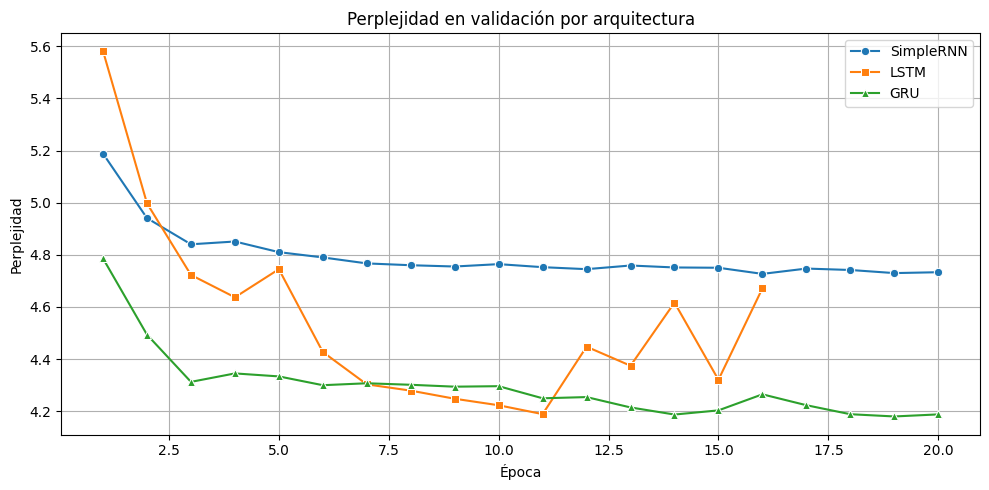

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))

epoch_count_rnn  = range(1, len(history_ppl_rnn)  + 1)
epoch_count_lstm = range(1, len(history_ppl_lstm) + 1)
epoch_count_gru  = range(1, len(history_ppl_gru)  + 1)

sns.lineplot(x=epoch_count_rnn,  y=history_ppl_rnn,  marker='o', label='SimpleRNN', ax=ax)
sns.lineplot(x=epoch_count_lstm, y=history_ppl_lstm, marker='s', label='LSTM',      ax=ax)
sns.lineplot(x=epoch_count_gru,  y=history_ppl_gru,  marker='^', label='GRU',       ax=ax)

ax.set_title("Perplejidad en validación por arquitectura")
ax.set_xlabel("Época")
ax.set_ylabel("Perplejidad")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

**Análisis del gráfico:**

Las tres arquitecturas muestran una reducción de la perplejidad durante el entrenamiento, pero con comportamientos muy distintos:

**SimpleRNN:** Converge rápido en las primeras 2 épocas pero se estanca alrededor de 4.75, sin lograr mejoras significativas a partir de la época 5. Esto confirma lo mencionado anteriormente sobre el vanishing gradient: con una ventana de contexto de 100 caracteres, la SimpleRNN no puede propagar gradientes útiles a través de tantos pasos temporales, limitando su capacidad de aprendizaje.

**LSTM:** Muestra la convergencia más inestable de las tres: presenta picos y valles pronunciados a lo largo de todo el entrenamiento (notablemente en las épocas 12, 14 y 16). Sin embargo, alcanza valores de perplejidad mínima cercanos a 4.2, comparables a los de la GRU.

**GRU:** Es la arquitectura con mejor comportamiento general. Desciende de forma suave y sostenida desde la época 1 (~4.78) hasta estabilizarse alrededor de 4.2 en la época 13. Esto la convierte en la opción más confiable para este tp ya que logra la misma perplejidad mínima que la LSTM pero con
una curva de entrenamiento mucho más estable.

**Conclusión:** Se selecciona la GRU como modelo final por su mejor balance.

In [96]:
# cargo el mejor modelo
model = keras.models.load_model('/content/best_gru_final.keras')

### 9. Generación de secuencias

In [97]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

#### Greedy Search

In [98]:
# Generación greedy con múltiples semillas para comparar comportamientos
seeds = [
    "el conde dracula ",
    "hace cincuenta años ",
    "la sangre de ",
    "caer la noche ",
]

print("=== Greedy Search — múltiples semillas ===\n")
for seed in seeds:
    result = generate_seq(model, seed, max_length=max_context_size, n_words=100)
    print(f"Semilla : '{seed}'")
    print(f"Generado: '{result}'")
    print("-" * 70)

=== Greedy Search — múltiples semillas ===

Semilla : 'el conde dracula '
Generado: 'el conde dracula de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa d'
----------------------------------------------------------------------
Semilla : 'hace cincuenta años '
Generado: 'hace cincuenta años de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa d'
----------------------------------------------------------------------
Semilla : 'la sangre de '
Generado: 'la sangre de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de l'
----------------------------------------------------------------------
Semilla : 'caer la noche '
Generado: 'caer la noche estaba en el conde había ser con la mano de la casa de la casa de la casa de la casa de la casa de l'
----------------------------------------------------------------------


**Conclusiones del Greedy Search**

Greedy search elige en cada paso el token más probable de forma local, lo que no garantiza la secuencia globalmente óptima. Esto se refleja en la tendencia a caer en loops constantes y en texto poco variado.

####  Beam search deterministico

In [99]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [100]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [101]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=80,input="el conde dracula ")

In [102]:
# veamos las salidas
decode(salidas[0])

'el conde dracula de la puerta de la señora harker después de todo lo que había estado de la puert'

**Conclusiones Beam Search Deterministico**

A diferencia de greedy search, este metodo busca en cada paso el mejor candidato dentro de un conjunto de alternativas (beams). En el modo determinístico, en cada paso se seleccionan los num_beams candidatos con mayor log-probabilidad acumulada, sin introducir aleatoriedad.

Como podemos observar en el resultado de la semilla "el conde dracula" esta tiene un mejor resultado al evitar el loop que teniamos con greedy search. Si bien la semantica de la oracion no tiene mucho sentido podemos afirmar que el resultado logrado es mejor.

#### Beam Search Estocastico

Como explicamos anteriormente, vamos a realizar algunas pruebas modificando la temperatura en el beam search.
Con temperaturas cercanas a cero el modelo deberia devolvernos respuestas similares en cada corrida. A medida que aumentamos la temperatura el modelo tendra mayor libertad y por lo tanto las respuestas deberian variar.

In [103]:
print("=== Beam Search Estocástico — Temperatura BAJA (T=0.2) ===\n")
seed = "el conde dracula "
for i in range(3):
    salidas_sto_low = beam_search(model, num_beams=10, num_words=80,
                                   input=seed, temp=0.2, mode='sto')
    print(f"Run {i+1}: {decode(salidas_sto_low[0])}\n")

=== Beam Search Estocástico — Temperatura BAJA (T=0.2) ===

Run 1: el conde dracula de la casa de la casa de la casa de la casa de la casa de la casa de la casa de 

Run 2: el conde dracula de la casa de la casa de la casa de la casa de la casa de la casa de la casa de 

Run 3: el conde dracula de la casa de la casa de la casa de la casa de la casa de la casa de la casa de 



In [104]:
print("=== Beam Search Estocástico — Temperatura ALTA (T=1.5) ===\n")
seed = "el conde dracula "
for i in range(3):
    salidas_sto_high = beam_search(model, num_beams=10, num_words=80,
                                    input=seed, temp=1.5, mode='sto')
    print(f"Run {i+1}: {decode(salidas_sto_high[0])}\n")

=== Beam Search Estocástico — Temperatura ALTA (T=1.5) ===

Run 1: el conde dracula de la puerta y los esperos de la mano de la luz del conde, y como lo estaba desa

Run 2: el conde dracula de los labios, sino que había decir, y después de tiene el profesor y me había e

Run 3: el conde dracula que pareció que había sucedido con una cosa que estaba para ella, pero lo cual n



Como vemos en los ejemplos anteriores, con temperatura baja (T=0.2) la distribución de probabilidades se vuelve más concentrada, priorizando los tokens más probables. El resultado es más coherente y repetible entre corridas, comportándose de forma similar al beam search determinístico.

A medida que aumentamos la temperatura (T=1.5), la distribución se aplana: tokens menos probables tienen más chances de ser seleccionados, lo que genera texto más variado y "creativo" pero potencialmente menos coherente.

En el límite, con T→∞ el muestreo se aproxima a una distribución uniforme (cualquier token es igualmente probable), mientras que con T→0 el modelo converge al comportamiento determinístico.

### 10. Comparacion de Modelos LSTM y GRU - Resumen

In [105]:
# Comparación de generación: LSTM vs GRU con las mismas semillas y estrategias

model_lstm_saved = keras.models.load_model('/content/best_lstm_final.keras')
model_gru_saved  = keras.models.load_model('/content/best_gru_final.keras')
model_rnn_saved = keras.models.load_model('/content/best_rnn_final.keras')

seeds = ["el conde dracula ", "la sangre de "]
n_chars = 100

for seed in seeds:
    print(f"\n{'='*70}")
    print(f"SEMILLA: '{seed}'")
    print(f"{'='*70}")

    # Greedy
    print("\n--- Greedy Search ---")
    print(f"  SimpleRNN: {generate_seq(model_rnn_saved,  seed, max_context_size, n_chars)}")
    print(f"  LSTM:      {generate_seq(model_lstm_saved, seed, max_context_size, n_chars)}")
    print(f"  GRU:       {generate_seq(model_gru_saved,  seed, max_context_size, n_chars)}")

    # Beam determinístico
    print("\n--- Beam Search Determinístico (beams=10) ---")
    print(f"  SimpleRNN: {decode(beam_search(model_rnn_saved,  10, n_chars, seed)[0])}")
    print(f"  LSTM:      {decode(beam_search(model_lstm_saved, 10, n_chars, seed)[0])}")
    print(f"  GRU:       {decode(beam_search(model_gru_saved,  10, n_chars, seed)[0])}")

    # Beam estocástico T=0.5
    print("\n--- Beam Search Estocástico T=0.5 ---")
    print(f"  SimpleRNN: {decode(beam_search(model_rnn_saved,  10, n_chars, seed, temp=0.5, mode='sto')[0])}")
    print(f"  LSTM:      {decode(beam_search(model_lstm_saved, 10, n_chars, seed, temp=0.5, mode='sto')[0])}")
    print(f"  GRU:       {decode(beam_search(model_gru_saved,  10, n_chars, seed, temp=0.5, mode='sto')[0])}")

    # Beam estocástico T=1.5
    print("\n--- Beam Search Estocástico T=1.5 ---")
    print(f"  SimpleRNN: {decode(beam_search(model_rnn_saved,  10, n_chars, seed, temp=1.5, mode='sto')[0])}")
    print(f"  LSTM:      {decode(beam_search(model_lstm_saved, 10, n_chars, seed, temp=1.5, mode='sto')[0])}")
    print(f"  GRU:       {decode(beam_search(model_gru_saved,  10, n_chars, seed, temp=1.5, mode='sto')[0])}")


SEMILLA: 'el conde dracula '

--- Greedy Search ---
  SimpleRNN: el conde dracula de la cabeza de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa
  LSTM:      el conde dracula de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa d
  GRU:       el conde dracula de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa de la casa d

--- Beam Search Determinístico (beams=10) ---
  SimpleRNN: el conde dracula de la ventana de la señora harker estaba después de la cabeza de la manera que estaba después de la 
  LSTM:      el conde dracula de la señora harker que estaba después de lo que estaba después de que estaba después de que estaba 
  GRU:       el conde dracula de la puerta de la señora harker después de todo lo que había estado de la puerta de la puerta de la

--- Beam Search Estocástico T=0.5 ---
  SimpleRNN: el conde dracula de la cabeza de la mano de que estaba como un

**Conclusiones finales**

La comparación entre las tres arquitecturas permite extraer conclusiones claras sobre el impacto del diseño en la calidad del texto generado.

La SimpleRNN mostró limitaciones evidentes: si bien converge rápido en las primeras épocas, se estanca en una perplejidad de ~4.75 y genera secuencias con menor coherencia léxica, confirmando el efecto del vanishing gradient.

La LSTM y la GRU lograron perplejidades similares (~4.2), pero la GRU lo hizo con una curva de entrenamiento más estable y sin las oscilaciones observadas en la LSTM. Por este motivo se seleccionó la GRU como modelo final.

Respecto a las estrategias de generación, el Greedy Search resultó en loops repetitivos para las tres arquitecturas, lo cual es esperable dado que siempre elige el token más probable localmente. El Beam Search determinístico mejoró notablemente la calidad al explorar múltiples hipótesis en paralelo. Finalmente, el Beam Search estocástico con temperatura alta (T=1.5) produjo el texto más variado y natural, a costa de algo de coherencia, mientras que con temperatura baja (T=0.2) el comportamiento se aproximó al determinístico.